### Load the libraries

In [8]:
options(warn = -1)
library(tidyverse)
library(fpp3)
library(strucchange)



### Read and prepare data

In [9]:

traffic_ts <- read_csv("Trafficstat(EN).csv", skip = 1) %>%
  transmute(
    DateMonth = yearmonth(paste(Year, Month, sep = "-")),
    Cars = Cars
  ) %>%
  filter(!is.na(Cars)) %>%
  as_tsibble(index = DateMonth)

New names:
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
Rows: 309 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (2): Year, Month
num (6): Motorcycles, Cars, Cars with trailer etc., Buses, Trucks and vans f...
lgl (5): ...9, ...10, ...11, ...12, ...13

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### Plot timeseries

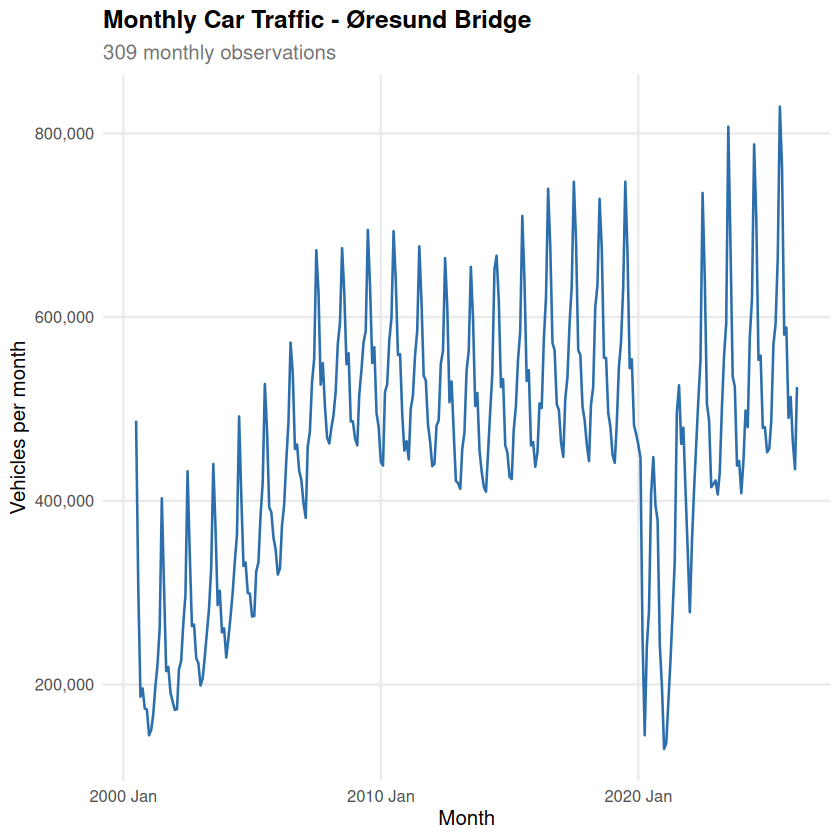

In [10]:
autoplot(traffic_ts, .vars = Cars, colour = "#2C6FAC") +
  labs(
    title    = "Monthly Car Traffic - Øresund Bridge",
    subtitle = "309 monthly observations",
    x        = "Month",
    y        = "Vehicles per month"
  ) +
  scale_y_continuous(labels = scales::comma) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title       = element_text(face = "bold"),
    plot.subtitle    = element_text(colour = "grey45"),
    panel.grid.minor = element_blank()
  )


### Transformation decison

In [11]:
lambda <- traffic_ts %>%
  features(Cars, features = guerrero) %>%
  pull(lambda_guerrero)
lambda  


[1] 0.7898781

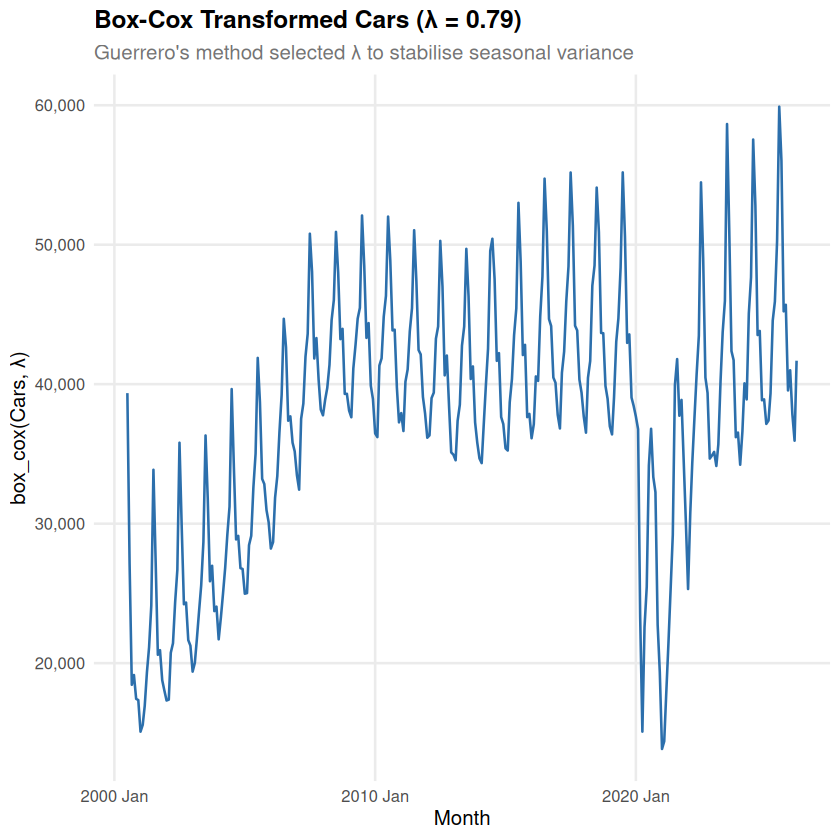

In [12]:

traffic_ts %>%
  autoplot(box_cox(Cars, lambda), colour = "#2C6FAC") +
  labs(
    title = "Box-Cox Transformed Cars (λ = 0.79)",
    subtitle = "Guerrero's method selected λ to stabilise seasonal variance",
    x = "Month", y = "box_cox(Cars, λ)"
  ) +
  scale_y_continuous(labels = scales::comma) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title       = element_text(face = "bold"),
    plot.subtitle    = element_text(colour = "grey45"),
    panel.grid.minor = element_blank()
  )


### Seasonality

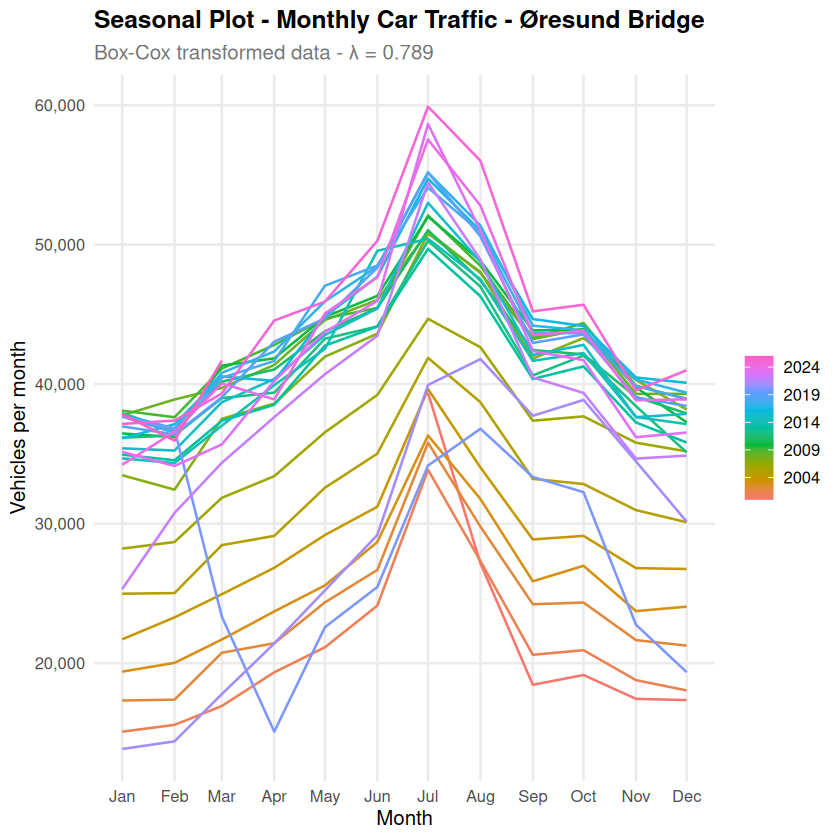

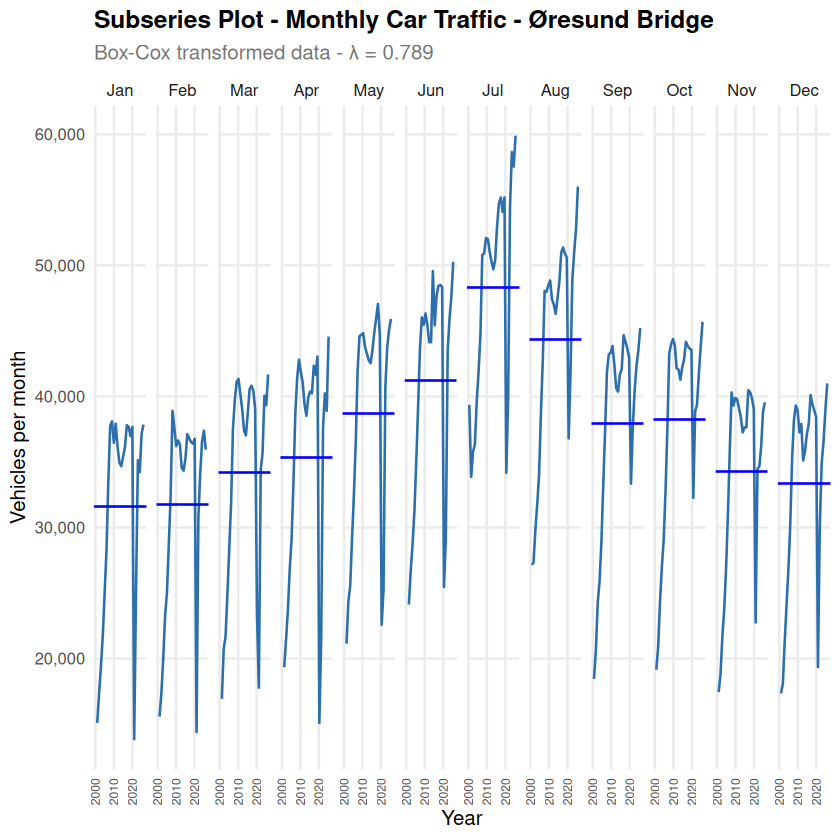

In [13]:
traffic_ts %>% gg_season(box_cox(Cars, lambda)) +
    labs(
        title = "Seasonal Plot - Monthly Car Traffic - Øresund Bridge",
        subtitle = "Box-Cox transformed data - λ = 0.789",
        x = "Month",
        y = "Vehicles per month"
    ) +
    scale_y_continuous(labels = scales::comma) +
    theme_minimal(base_size = 12) +
    theme(
    plot.title       = element_text(face = "bold"),
    plot.subtitle    = element_text(color = "grey45"),
    panel.grid.minor = element_blank()
  )

traffic_ts %>% gg_subseries(box_cox(Cars, lambda), color = "#2C6FAC") +
  labs(
    title    = "Subseries Plot - Monthly Car Traffic - Øresund Bridge",
    subtitle = "Box-Cox transformed data - λ = 0.789",
    x        = "Year",
    y        = "Vehicles per month"
  ) +
  scale_y_continuous(labels = scales::comma) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title       = element_text(face = "bold"),
    plot.subtitle    = element_text(color = "grey45"),
    panel.grid.minor = element_blank(),
    axis.text.x      = element_text(angle = 90, vjust = 0.5, size = 7)
  )




### Stationary


In [14]:
# feasts has no built-in unitroot_adf; wrap tseries::adf.test (already loaded via feasts)
unitroot_adf <- function(x, ...) {
  result <- tseries::adf.test(na.omit(x))
  c(adf_stat = unname(result$statistic), adf_pvalue = result$p.value)
}

# Test stationary on box_cox transformed data
traffic_ts %>%
  features(box_cox(Cars, lambda), features = list(
    unitroot_kpss,
    unitroot_adf,
    unitroot_ndiffs,
    unitroot_nsdiffs
  ))

# Test stationary on d=1 D=1 
traffic_ts %>%
  mutate(diff2 = difference(difference(box_cox(Cars, lambda), 12), 1)) %>%
  filter(!is.na(diff2)) %>%
  features(diff2, features = list(unitroot_kpss, unitroot_adf))

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



kpss_stat,kpss_pvalue,adf_stat,adf_pvalue,ndiffs,nsdiffs
<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
1.609571,0.01,-2.925084,0.1863859,1,1


kpss_stat,kpss_pvalue,adf_stat,adf_pvalue
<dbl>,<dbl>,<dbl>,<dbl>
0.02956613,0.1,-6.91269,0.01


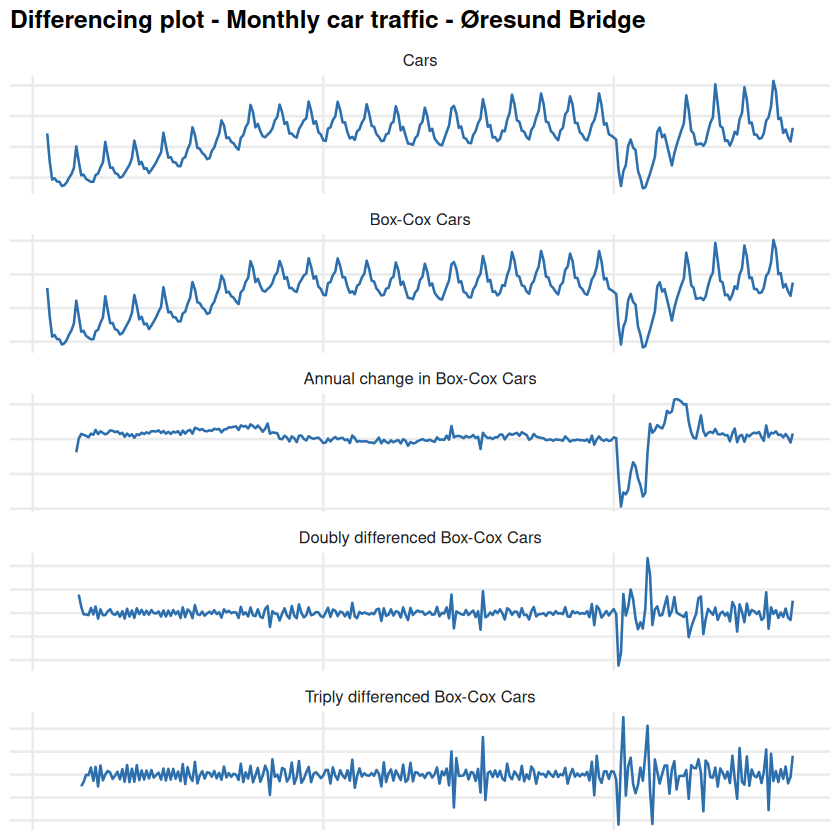

In [15]:
traffic_ts %>%
  summarise(Cars = sum(Cars)/1e4) |>
  transmute(
    `Cars` = Cars,
    `Box-Cox Cars` = box_cox(Cars, lambda),
    `Annual change in Box-Cox Cars` = difference(box_cox(Cars, lambda), 12),
    `Doubly differenced Box-Cox Cars` = difference(difference(box_cox(Cars, lambda), 12), 1),
    `Triply differenced Box-Cox Cars` = difference(difference(difference(box_cox(Cars, lambda), 12), 1), 1)
  ) %>%
  pivot_longer(-DateMonth, names_to = "Type", values_to = "Cars") |>
  mutate(
    Type = factor(Type, levels = c(
      "Cars",
      "Box-Cox Cars",
      "Annual change in Box-Cox Cars",
      "Doubly differenced Box-Cox Cars",
      "Triply differenced Box-Cox Cars"))
  ) %>%
  ggplot(aes(x = DateMonth, y = Cars)) +
  geom_line(color = "#2C6FAC") +
  facet_wrap(~ Type, ncol = 1, scales = "free_y", labeller = label_wrap_gen(width = 35)) +
  labs(title = "Differencing plot - Monthly car traffic - Øresund Bridge",
       y = NULL, x = NULL) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title       = element_text(face = "bold"),
    axis.text.y      = element_blank(),
    axis.ticks.y     = element_blank(),
    axis.text.x      = element_blank(),
    axis.ticks.x     = element_blank(),
    panel.grid.minor = element_blank()
  )


### ACF/PACF

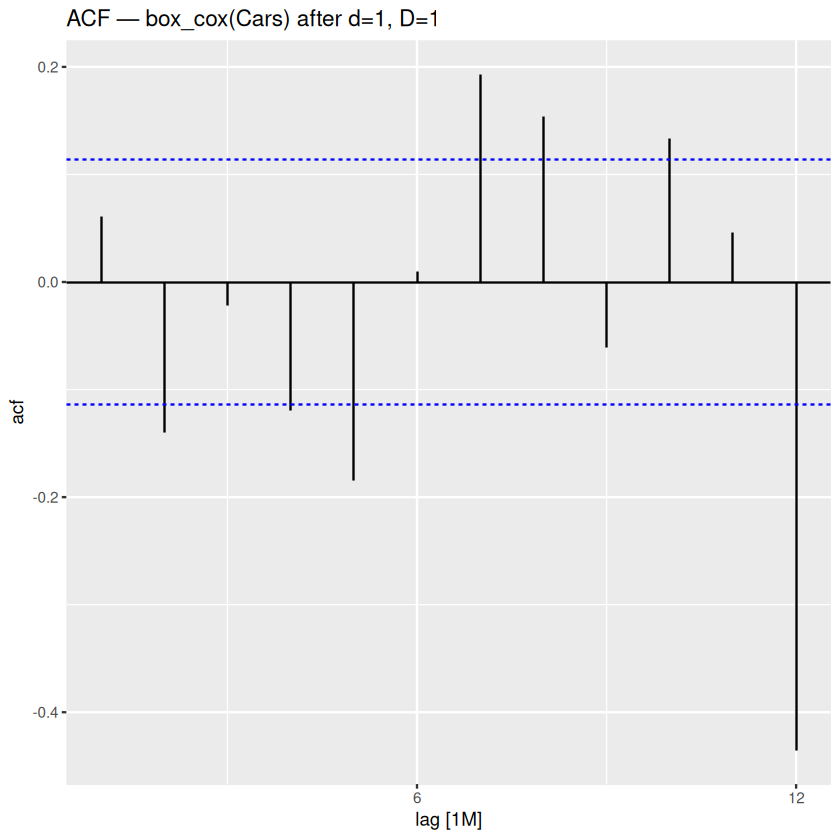

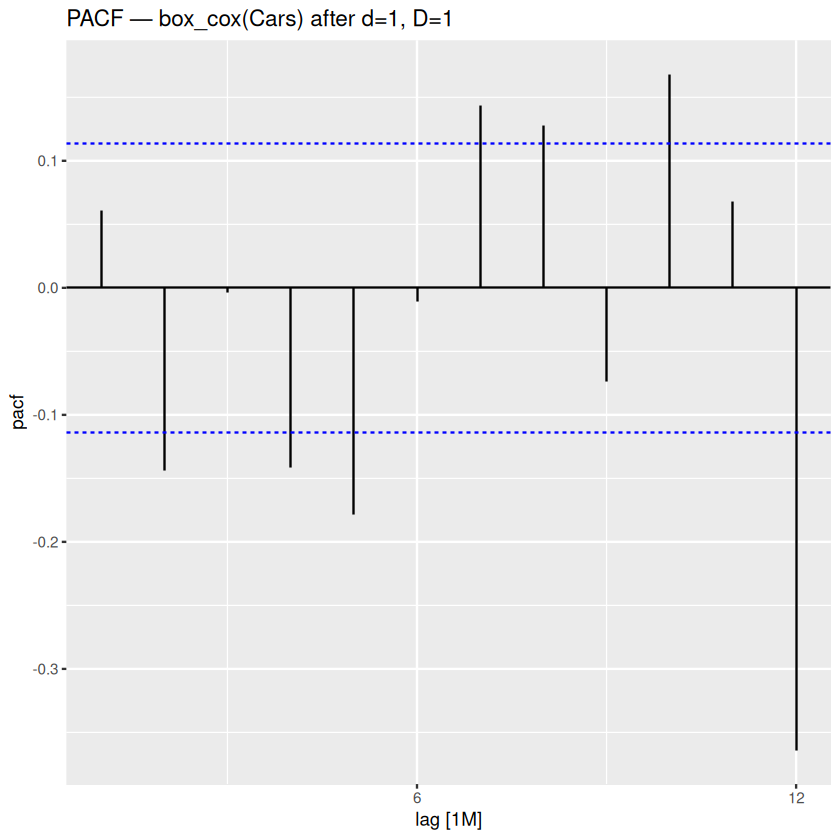

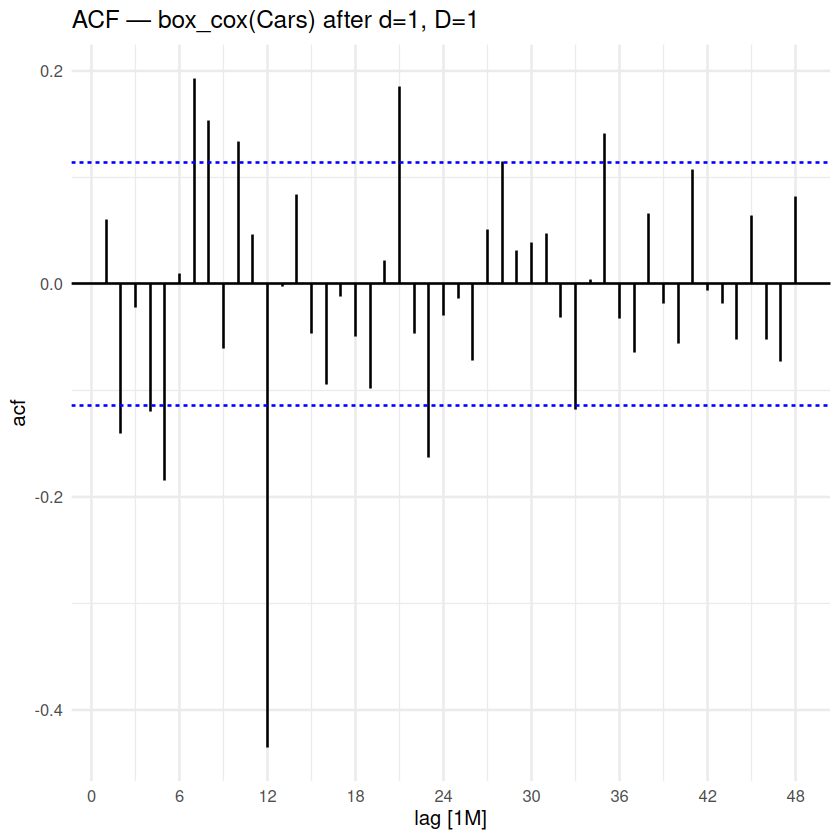

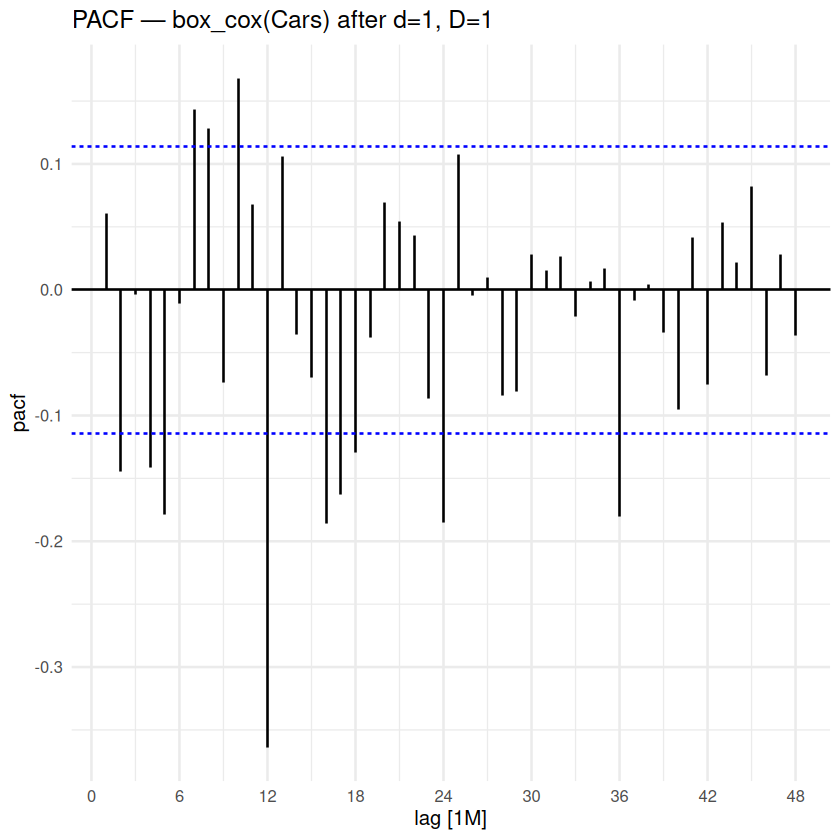

In [16]:
# This shows the ACF/PACF for 12/48 months. We use this to determine ARIMA parameters

traffic_ts %>%
  mutate(transformed_cars = box_cox(Cars, lambda)) %>%
  transmute(diff_cars = difference(difference(transformed_cars, 12), 1)) %>%
  filter(!is.na(diff_cars)) %>%
  ACF(diff_cars, lag_max = 12) %>%
  autoplot() + labs(title = "ACF — box_cox(Cars) after d=1, D=1")

traffic_ts %>%
  mutate(transformed_cars = box_cox(Cars, lambda)) %>%
  transmute(diff_cars = difference(difference(transformed_cars, 12), 1)) %>%
  filter(!is.na(diff_cars)) %>%
  PACF(diff_cars, lag_max = 12) %>%
  autoplot() + labs(title = "PACF — box_cox(Cars) after d=1, D=1")


traffic_ts %>%
  mutate(transformed_cars = box_cox(Cars, lambda)) %>%
  transmute(diff_cars = difference(difference(transformed_cars, 12), 1)) %>%
  filter(!is.na(diff_cars)) %>%
  ACF(diff_cars, lag_max = 48) %>%
  autoplot() + 
    labs(
      title = "ACF — box_cox(Cars) after d=1, D=1") +
    theme_minimal(base_size = 12) 


traffic_ts %>%
  mutate(transformed_cars = box_cox(Cars, lambda)) %>%
  transmute(diff_cars = difference(difference(transformed_cars, 12), 1)) %>%
  filter(!is.na(diff_cars)) %>%
  PACF(diff_cars, lag_max = 48) %>%
  autoplot() + labs(title = "PACF — box_cox(Cars) after d=1, D=1") +
    theme_minimal(base_size = 12)


### Handling COVID

In [17]:
# Robust STL pushes outlier signal into remainder; z-scores identify which months are extreme
stl_remainder <- traffic_ts %>%
  model(STL(Cars ~ trend(window = 13), robust = TRUE)) %>%
  components() %>%
  as_tibble() %>%
  mutate(z_remainder = (remainder - mean(remainder)) / sd(remainder))

# Show the data-estimated COVID window
stl_remainder %>%
  filter(abs(z_remainder) > 2) %>%
  select(DateMonth, Cars, remainder, z_remainder) %>%
  arrange(DateMonth)


DateMonth,Cars,remainder,z_remainder
<mth>,<dbl>,<dbl>,<dbl>
2000 Jul,487229,122037.98,3.488878
2014 Jun,652354,81874.76,2.353930
2020 Mar,251316,-194861.81,-5.466199
2020 Apr,144759,-286944.92,-8.068320
2020 May,241158,-218818.41,-6.143174
2020 Jun,280692,-187811.39,-5.266966
2020 Jul,407410,-129693.22,-3.624640
2020 Sep,394952,70237.58,2.025082
2020 Oct,378768,69377.28,2.000771


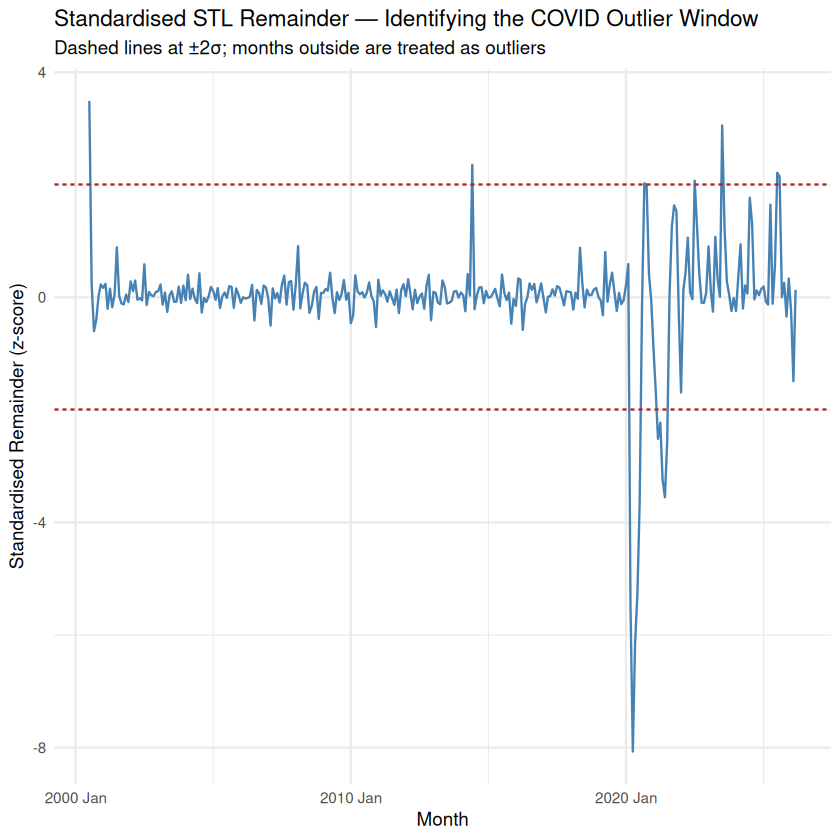

In [18]:
# Plot the outliers
stl_remainder %>%
  ggplot(aes(x = DateMonth, y = z_remainder)) +
  geom_line(color = "steelblue") +
  geom_hline(yintercept = c(-2, 2), linetype = "dashed", color = "firebrick") +
  labs(
    title = "Standardised STL Remainder — Identifying the COVID Outlier Window",
    subtitle = "Dashed lines at ±2σ; months outside are treated as outliers",
    x = "Month", y = "Standardised Remainder (z-score)"
  ) +
  theme_minimal()


In [19]:
# Test to see if DGP changed after covid
traffic_df_diff <- traffic_ts %>%
  as_tibble() %>%
  mutate(
    diff_cars = difference(difference(box_cox(Cars, lambda), 12), 1)
  ) %>%
  filter(!is.na(diff_cars))

formula_diff <- diff_cars ~ 1 


chow_diff <- sctest(formula_diff, data = traffic_df_diff, type = "Chow",
                    point = which(traffic_df_diff$DateMonth == yearmonth("2021 Aug")))
chow_diff



	Chow test

data:  formula_diff
F = 0.059163, p-value = 0.808



	supF test

data:  fs
sup.F = 2.3692, p-value = 0.6973


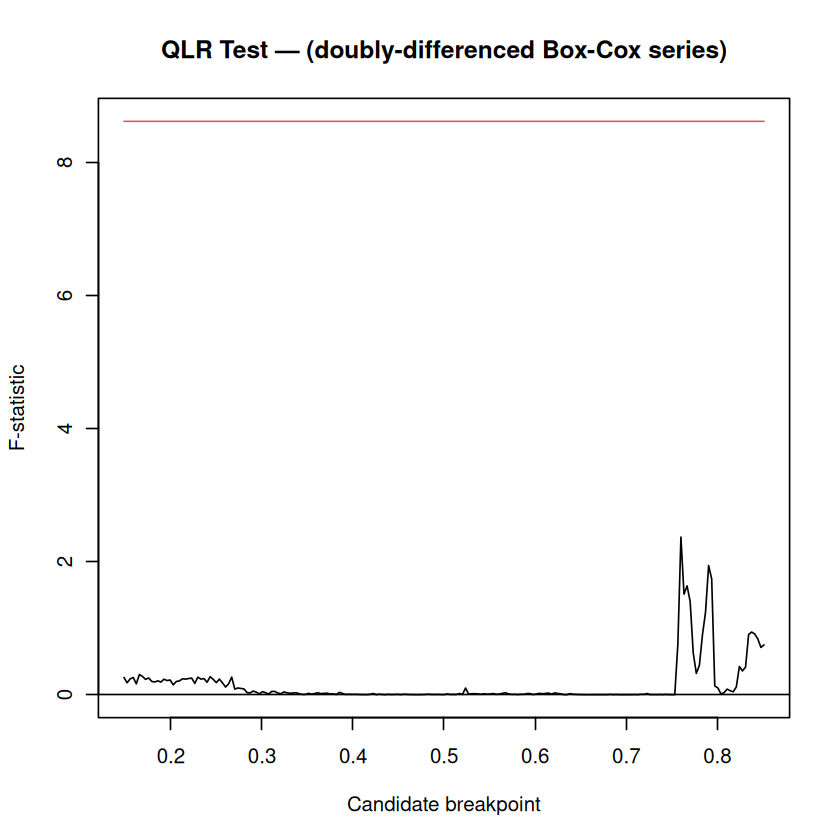

In [20]:
# QLR test (Quandt Likelihood Ratio / supremum-F)

fs <- Fstats(formula_diff, data = traffic_df_diff)

qlr_result <- sctest(fs, type = "supF")
qlr_result

plot(fs,
     main = "QLR Test — (doubly-differenced Box-Cox series)",
     xlab = "Candidate breakpoint",
     ylab = "F-statistic")


In [21]:
# Handle covid for our ARIMA model
# Note we use both a covid var for general covid months and 3 more for worst outliers within covid
covid_start <- yearmonth("2020 Mar")
covid_end   <- yearmonth("2021 Jul") 

traffic_ts <- traffic_ts %>%
  mutate(
    covid = if_else(DateMonth >= covid_start & DateMonth <= covid_end, 1L, 0L),
    imp_2020_apr = if_else(DateMonth == yearmonth("2020 Apr"), 1L, 0L),
    imp_2020_may = if_else(DateMonth == yearmonth("2020 May"), 1L, 0L),
    imp_2020_mar = if_else(DateMonth == yearmonth("2020 Mar"), 1L, 0L)
  )


## Models

### ARIMA

In [22]:
# Two predicted arima models plus auto arima

fit <- traffic_ts %>%
  model(
    arima010011 = ARIMA(box_cox(Cars, lambda) ~ covid +
                          imp_2020_apr + imp_2020_may + imp_2020_mar +
                          pdq(0,1,0) + PDQ(0,1,1)),
    auto = ARIMA(box_cox(Cars, lambda) ~ covid +
                   imp_2020_apr + imp_2020_may + imp_2020_mar,
                 stepwise = FALSE, approximation = FALSE),
    arima212011 = ARIMA(box_cox(Cars, lambda) ~ covid +
                          imp_2020_apr + imp_2020_may + imp_2020_mar +
                          pdq(2,1,2) + PDQ(0,1,1)),
    arimaNoCovidVars = ARIMA(box_cox(Cars, lambda) ~
                          pdq(2,1,2) + PDQ(0,1,1)),
    arimaNoImpulse = ARIMA(box_cox(Cars, lambda) ~ covid +
                      pdq(2,1,2) + PDQ(0,1,1)),
                        
  )


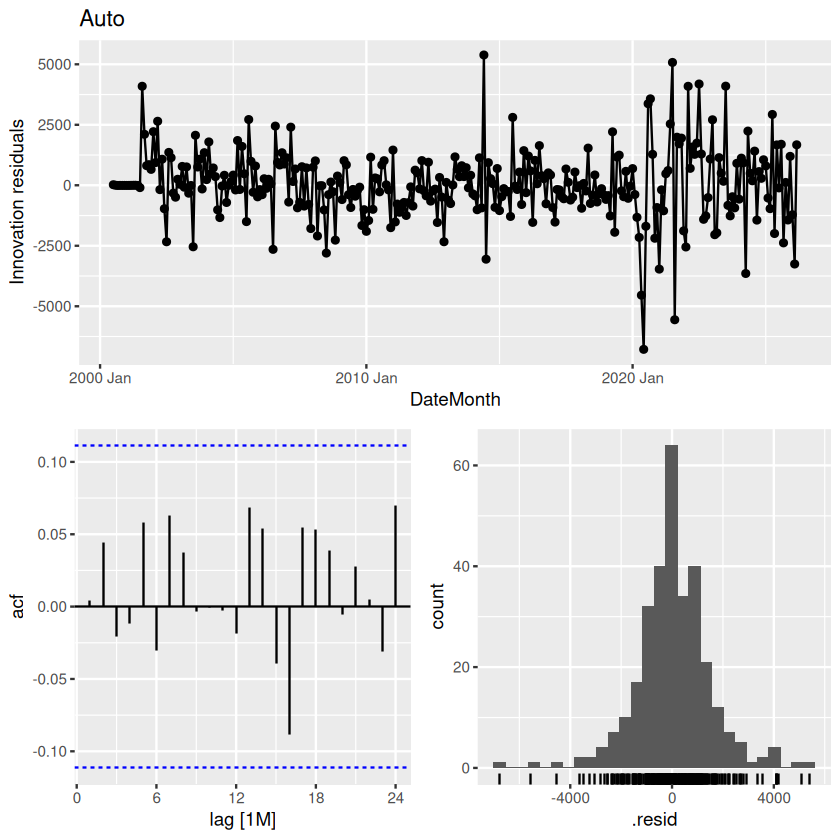

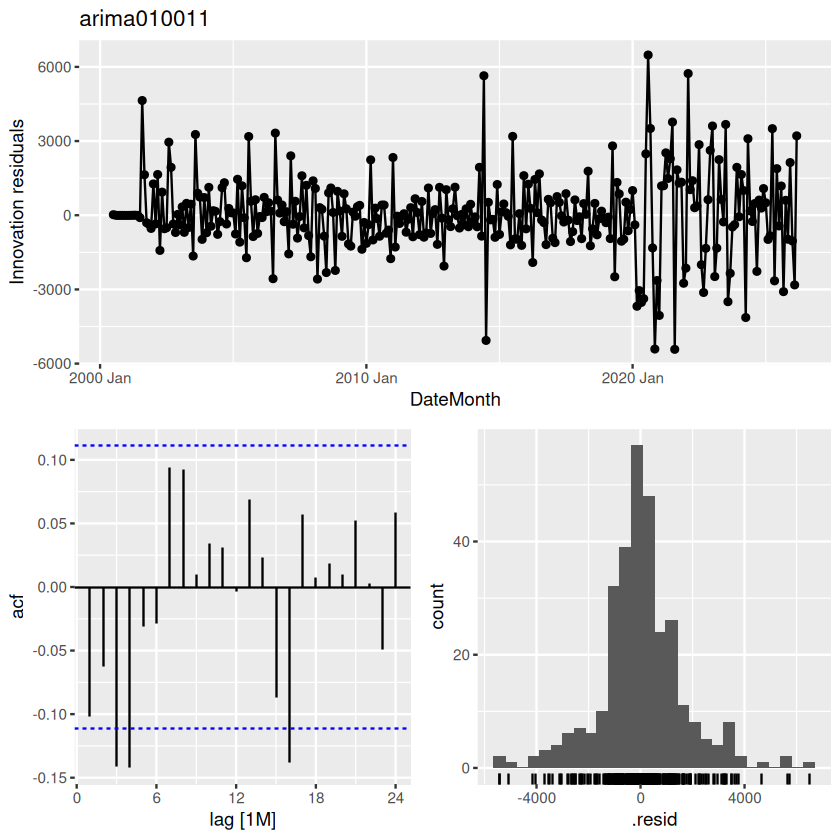

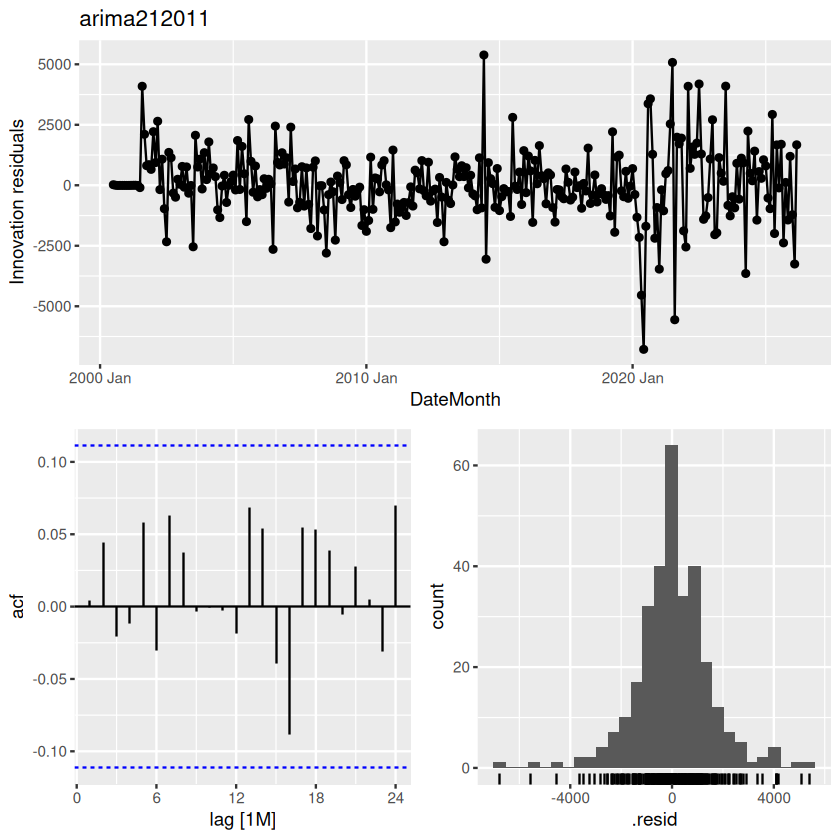

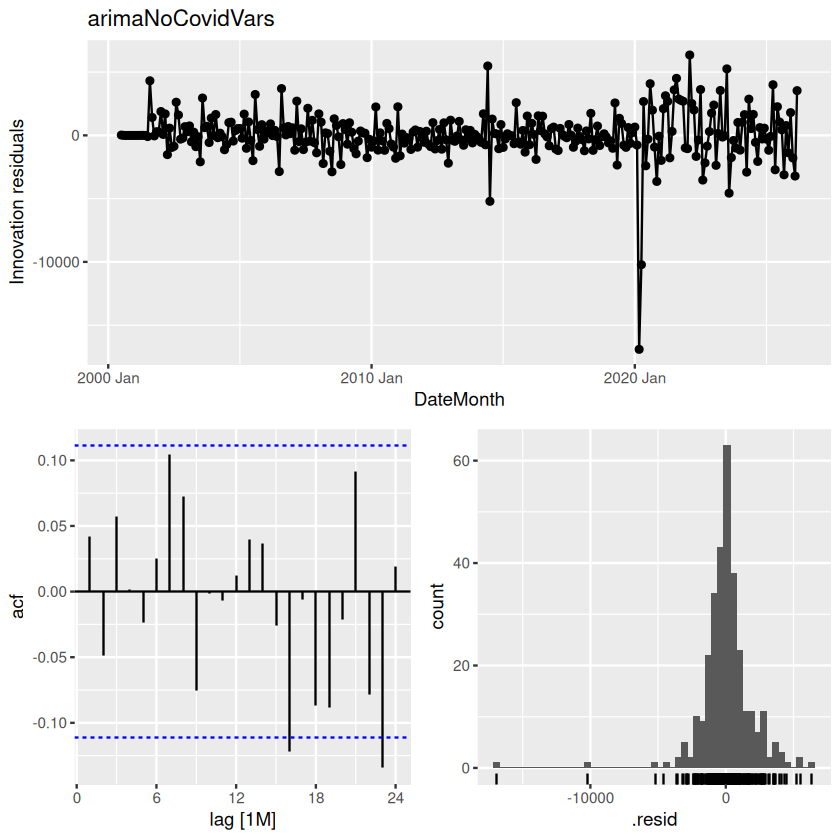


=== auto ===
Series: Cars 
Model: LM w/ ARIMA(2,1,2)(0,1,1)[12] errors 
Transformation: box_cox(Cars, lambda) 

Coefficients:
         ar1      ar2      ma1     ma2     sma1        covid  imp_2020_apr
      1.4459  -0.6691  -1.8300  0.9468  -0.6923  -12437.7935    -11833.515
s.e.  0.0592   0.0549   0.0332  0.0299   0.0520     805.9893      1326.676
      imp_2020_may  imp_2020_mar
         -4417.173     -3121.684
s.e.      1239.823      1256.700

sigma^2 estimated as 2240333:  log likelihood=-2583.94
AIC=5187.87   AICc=5188.64   BIC=5224.78

=== arima010011 ===
Series: Cars 
Model: LM w/ ARIMA(0,1,0)(0,1,1)[12] errors 
Transformation: box_cox(Cars, lambda) 

Coefficients:
         sma1      covid  imp_2020_apr  imp_2020_may  imp_2020_mar
      -0.6946  -9148.320    -11157.065     -3536.265     -3929.760
s.e.   0.0514   1352.364      1653.771      1349.484      1653.248

sigma^2 estimated as 2721542:  log likelihood=-2614.31
AIC=5240.62   AICc=5240.91   BIC=5262.76

=== arima212011 ===

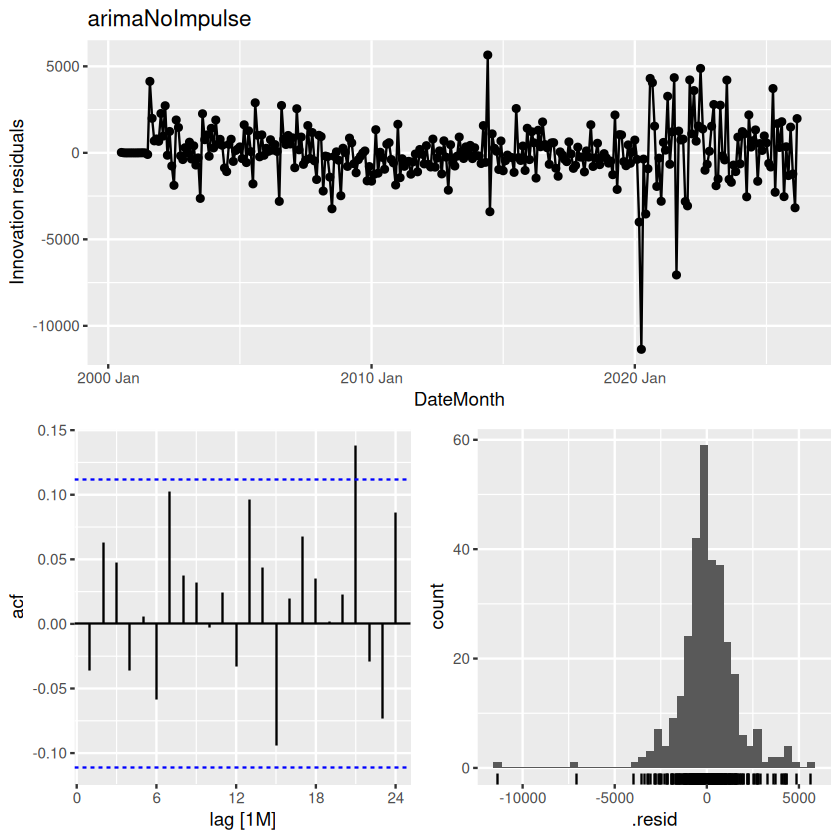

In [23]:
# Residual check for our ARIMA models
fit %>% select(auto)             %>% gg_tsresiduals() +
    labs(title = "Auto")
fit %>% select(arima010011)      %>% gg_tsresiduals() +
    labs(title = "arima010011")
fit %>% select(arima212011)      %>% gg_tsresiduals() +
    labs(title = "arima212011")
fit %>% select(arimaNoCovidVars) %>% gg_tsresiduals() +
    labs(title = "arimaNoCovidVars")
fit %>% select(arimaNoImpulse)   %>% gg_tsresiduals() +
    labs(title = "arimaNoImpulse")



cat("\n=== auto ===\n");            fit %>% select(auto)            %>% report()
cat("\n=== arima010011 ===\n");     fit %>% select(arima010011)     %>% report()
cat("\n=== arima212011 ===\n");     fit %>% select(arima212011)     %>% report()
cat("\n=== arimaNoCovidVars ===\n"); fit %>% select(arimaNoCovidVars) %>% report()
cat("\n=== arimaNoImpulse ===\n");  fit %>% select(arimaNoImpulse)  %>% report()




In [24]:
# Note that DOF was calculated based on https://robjhyndman.com/hyndsight/ljung_box_df.html
# DOF = p+q, seasonal only, no regressors

fit %>% select(arima010011) %>% residuals() %>%
  features(.resid, ljung_box, lag = 24, dof = 0)

fit %>% select(arima212011) %>% residuals() %>%
  features(.resid, ljung_box, lag = 24, dof = 4)  

fit %>% select(arimaNoImpulse) %>% residuals() %>%
  features(.resid, ljung_box, lag = 24, dof = 4)  

fit %>% select(arimaNoCovidVars) %>% residuals() %>%
  features(.resid, ljung_box, lag = 24, dof = 4) 


.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
arima010011,38.52861,0.0305842


.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
arima212011,14.22552,0.8188799


.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
arimaNoImpulse,28.27264,0.1031009


.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
arimaNoCovidVars,32.03884,0.04288622


In [25]:
# Expanding-window CV
# arima213011 tested for validation
traffic_cv <- traffic_ts %>%
  stretch_tsibble(.init = 120, .step = 12)

fit_cv <- traffic_cv %>%
  model(
    arima010011 = ARIMA(box_cox(Cars, lambda) ~ covid +
                          imp_2020_apr + imp_2020_may + imp_2020_mar +
                          pdq(0,1,0) + PDQ(0,1,1)),
    arima212011 = ARIMA(box_cox(Cars, lambda) ~ covid +
                          imp_2020_apr + imp_2020_may + imp_2020_mar +
                          pdq(2,1,2) + PDQ(0,1,1)),
    arima213011 = ARIMA(box_cox(Cars, lambda) ~ covid +
                          imp_2020_apr + imp_2020_may + imp_2020_mar +
                          pdq(2,1,3) + PDQ(0,1,1)),
    arimaNoCovidVars = ARIMA(box_cox(Cars, lambda) ~
                      pdq(2,1,2) + PDQ(0,1,1)),
    arimaNoImpulse =  ARIMA(box_cox(Cars, lambda) ~ covid +
                          pdq(2,1,3) + PDQ(0,1,1)),
    )


fold_cutoffs <- traffic_cv %>%
  as_tibble() %>%
  group_by(.id) %>%
  summarise(cutoff = max(DateMonth), .groups = "drop")

new_data_cv <- bind_rows(
  lapply(seq_len(nrow(fold_cutoffs)), function(i) {
    traffic_ts %>%
      filter(DateMonth > fold_cutoffs$cutoff[i]) %>%
      head(24) %>%
      as_tibble() %>%
      mutate(.id = fold_cutoffs$.id[i])
  })
) %>%
  as_tsibble(index = DateMonth, key = .id)

fc_cv <- fit_cv %>% forecast(new_data = new_data_cv)


cv_preds <- fc_cv %>%
  as_tibble() %>%
  group_by(.id, .model) %>%
  mutate(h = row_number()) %>%
  ungroup()

actuals <- traffic_ts %>% as_tibble() %>% select(DateMonth, Cars)

cv_acc <- cv_preds %>%
  select(.id, .model, DateMonth, h, .mean) %>%
  left_join(actuals, by = "DateMonth") %>%
  filter(h %in% c(6, 12, 24)) %>%
  group_by(.model, h) %>%
  summarise(
    RMSE = sqrt(mean((.mean - Cars)^2, na.rm = TRUE)),
    MAE  = mean(abs(.mean - Cars),     na.rm = TRUE),
    MAPE = mean(abs((.mean - Cars) / Cars) * 100, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(h, RMSE)

cv_acc




.model,h,RMSE,MAE,MAPE
<chr>,<int>,<dbl>,<dbl>,<dbl>
arima212011,6,34859.22,27233.78,8.784577
arima213011,6,45023.81,32382.75,10.258945
arimaNoImpulse,6,48690.35,35182.84,10.990701
arimaNoCovidVars,6,51252.99,30984.81,8.360793
arima010011,6,96836.12,52510.84,16.107481
arima212011,12,36758.79,34152.08,6.924555
arima213011,12,40115.96,36131.13,7.251694
arimaNoImpulse,12,52442.96,47768.11,9.527906
arima010011,12,90712.23,60448.80,11.878824


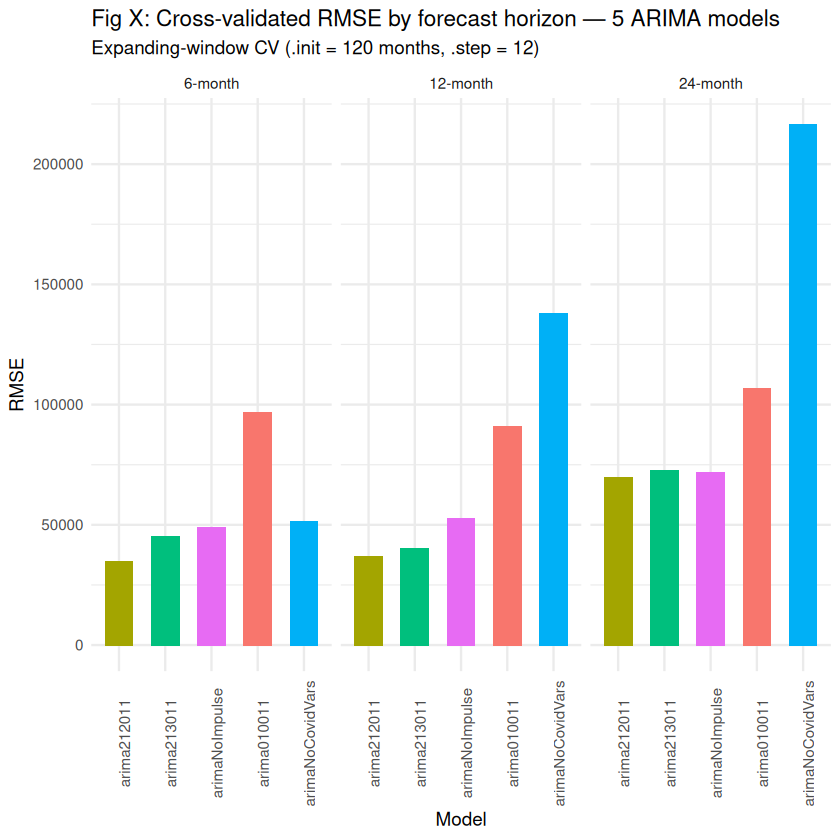

In [26]:
cv_acc %>%
  mutate(Horizon = factor(paste0(h, "-month"), levels = c("6-month", "12-month", "24-month"))) %>%
  ggplot(aes(x = reorder(.model, RMSE), y = RMSE, fill = .model)) +
  geom_col(width = 0.6) +
  facet_wrap(~ Horizon) +
  labs(
    title = "Fig X: Cross-validated RMSE by forecast horizon — 5 ARIMA models",
    subtitle = "Expanding-window CV (.init = 120 months, .step = 12)",
    x = "Model", y = "RMSE"
  ) +
  theme_minimal() +
  theme(legend.position = "none",
        axis.text.x = element_text(angle = 90)
  )


## Models

### ETS

In [27]:
# Five ETS models — STL variants handle COVID via robust decomposition; plain ETS serves as baseline
#   stl_auto  — auto ETS on STL-deseasonalised series
#   stl_AAN   — additive trend on STL-deseasonalised: persistent ACF/PACF pattern after differencing
#   stl_AAdN  — damped trend on STL-deseasonalised: subseries showed slowing growth
#   ets_auto  — auto ETS directly on series (no STL); baseline without COVID protection
#   ets_AAdA  — ETS(A,Ad,A) directly on series: additive errors (box-cox stabilises variance),
#               damped trend (slowing growth), additive seasonality (consistent seasonal shape)
fit_ets <- traffic_ts %>%
  model(
    stl_auto = decomposition_model(
      STL(box_cox(Cars, lambda) ~ trend(window = 21) + season(window = "periodic"),
          robust = TRUE),
      ETS(season_adjust ~ season("N"))
    ),
    stl_AAN = decomposition_model(
      STL(box_cox(Cars, lambda) ~ trend(window = 21) + season(window = "periodic"),
          robust = TRUE),
      ETS(season_adjust ~ error("A") + trend("A") + season("N"))
    ),
    stl_AAdN = decomposition_model(
      STL(box_cox(Cars, lambda) ~ trend(window = 21) + season(window = "periodic"),
          robust = TRUE),
      ETS(season_adjust ~ error("A") + trend("Ad") + season("N"))
    ),
    ets_auto = ETS(box_cox(Cars, lambda)),
    ets_AAdA = ETS(box_cox(Cars, lambda) ~ error("A") + trend("Ad") + season("A"))
  )

report(fit_ets %>% select(stl_auto))
report(fit_ets %>% select(stl_AAN))
report(fit_ets %>% select(stl_AAdN))
report(fit_ets %>% select(ets_auto))
report(fit_ets %>% select(ets_AAdA))

Series: Cars 
Model: STL decomposition model 
Transformation: box_cox(Cars, lambda) 
Combination: season_adjust + season_year


Series: season_adjust 
Model: ETS(A,N,N) 
  Smoothing parameters:
    alpha = 0.9998996 

  Initial states:
     l[0]
 22016.85

  sigma^2:  4147535

     AIC     AICc      BIC 
6484.146 6484.224 6495.346 

Series: season_year 
Model: SNAIVE 

sigma^2: 0 

Series: Cars 
Model: STL decomposition model 
Transformation: box_cox(Cars, lambda) 
Combination: season_adjust + season_year


Series: season_adjust 
Model: ETS(A,A,N) 
  Smoothing parameters:
    alpha = 0.9998994 
    beta  = 0.0005565744 

  Initial states:
     l[0]      b[0]
 23255.66 -61.10247

  sigma^2:  4132270

     AIC     AICc      BIC 
6484.987 6485.185 6503.653 

Series: season_year 
Model: SNAIVE 

sigma^2: 0 

Series: Cars 
Model: STL decomposition model 
Transformation: box_cox(Cars, lambda) 
Combination: season_adjust + season_year


Series: season_adjust 
Model: ETS(A,Ad,N) 
  Smoothing p

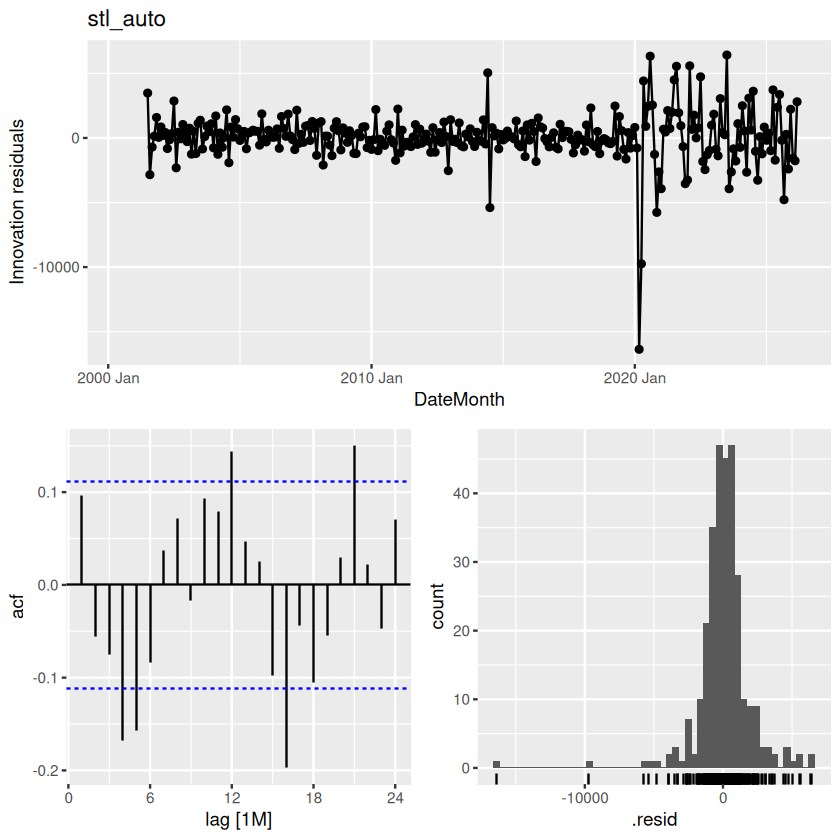

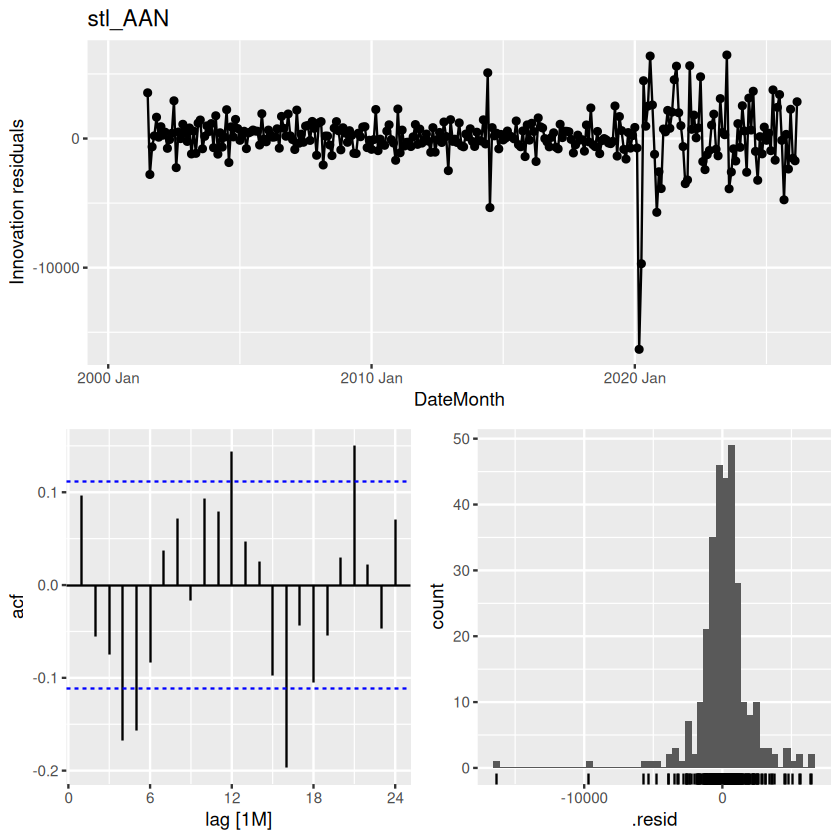

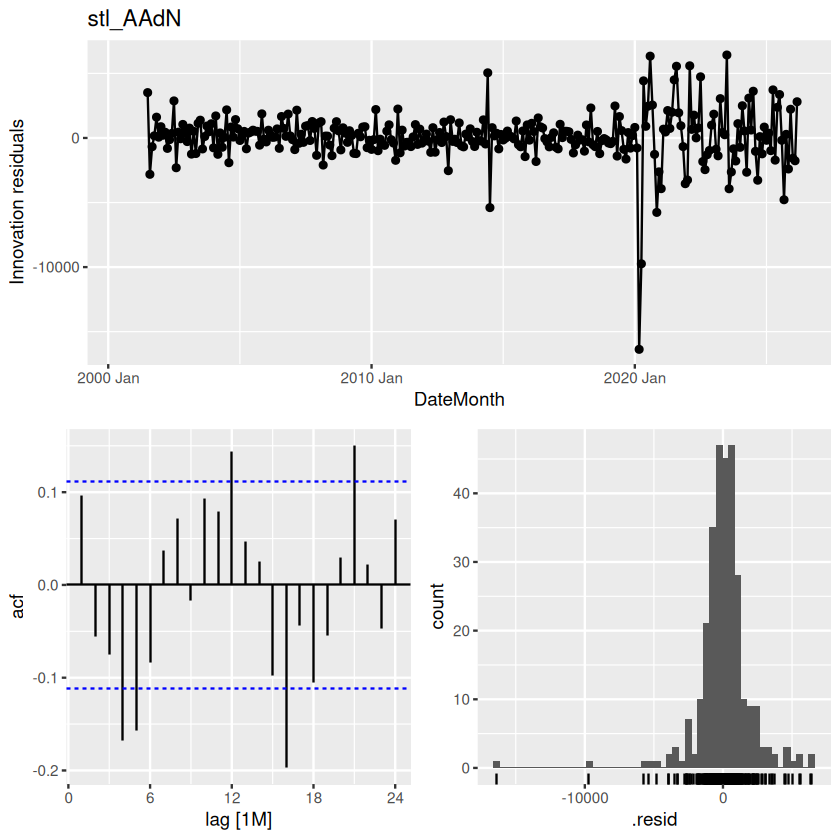

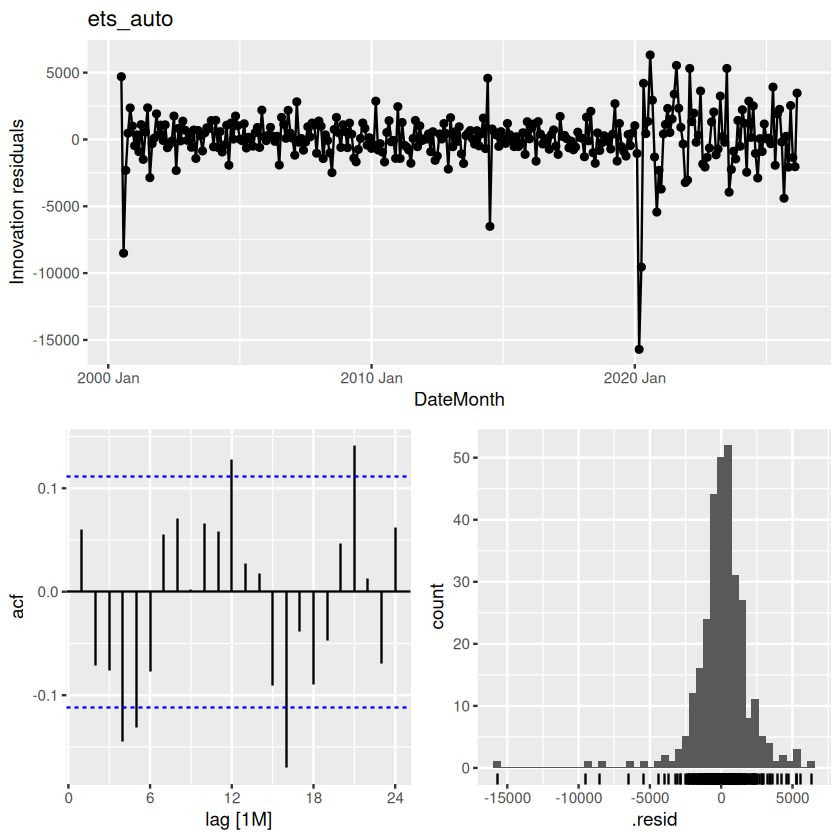

.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
stl_auto,68.06046,2.414455e-06


.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
stl_AAN,67.99364,1.363102e-06


.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
stl_AAdN,68.04466,7.206927e-07


.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
ets_auto,55.55859,9.888861e-05


.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
ets_AAdA,50.89303,0.0001648


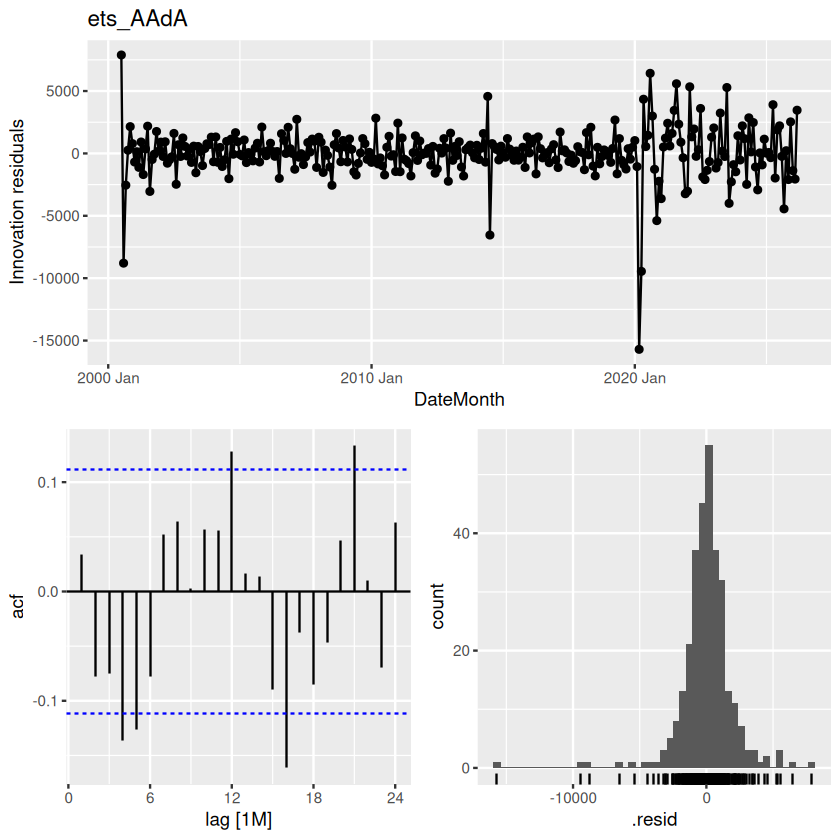

In [28]:
fit_ets %>% select(stl_auto)  %>% gg_tsresiduals() +
  labs(title = "stl_auto")
fit_ets %>% select(stl_AAN)   %>% gg_tsresiduals() +
  labs(title = "stl_AAN")
fit_ets %>% select(stl_AAdN)  %>% gg_tsresiduals() +
  labs(title = "stl_AAdN")
fit_ets %>% select(ets_auto)  %>% gg_tsresiduals() +
  labs(title = "ets_auto")
fit_ets %>% select(ets_AAdA)  %>% gg_tsresiduals() +
  labs(title = "ets_AAdA")

# dof = number of smoothing parameters in each model
fit_ets %>% select(stl_auto)  %>% residuals() %>%
  features(.resid, ljung_box, lag = 24, dof = 1)   # alpha

fit_ets %>% select(stl_AAN)   %>% residuals() %>%
  features(.resid, ljung_box, lag = 24, dof = 2)   # alpha + beta

fit_ets %>% select(stl_AAdN)  %>% residuals() %>%
  features(.resid, ljung_box, lag = 24, dof = 3)   # alpha + beta + phi

fit_ets %>% select(ets_auto)  %>% residuals() %>%
  features(.resid, ljung_box, lag = 24, dof = 2)   # alpha + gamma (ETS(A,N,A) has no trend)

fit_ets %>% select(ets_AAdA)  %>% residuals() %>%
  features(.resid, ljung_box, lag = 24, dof = 4)   # alpha + beta + phi + gamma

In [29]:
# Reuse the same expanding-window folds as the ARIMA CV for a fair comparison
fit_ets_cv <- traffic_cv %>%
  model(
    stl_auto = decomposition_model(
      STL(box_cox(Cars, lambda) ~ trend(window = 21) + season(window = "periodic"),
          robust = TRUE),
      ETS(season_adjust ~ season("N"))
    ),
    stl_AAN = decomposition_model(
      STL(box_cox(Cars, lambda) ~ trend(window = 21) + season(window = "periodic"),
          robust = TRUE),
      ETS(season_adjust ~ error("A") + trend("A") + season("N"))
    ),
    stl_AAdN = decomposition_model(
      STL(box_cox(Cars, lambda) ~ trend(window = 21) + season(window = "periodic"),
          robust = TRUE),
      ETS(season_adjust ~ error("A") + trend("Ad") + season("N"))
    ),
    ets_auto = ETS(box_cox(Cars, lambda)),
    ets_AAdA = ETS(box_cox(Cars, lambda) ~ error("A") + trend("Ad") + season("A"))
  )

fc_ets_cv <- fit_ets_cv %>% forecast(h = 24)

ets_cv_acc <- fc_ets_cv %>%
  as_tibble() %>%
  group_by(.id, .model) %>%
  mutate(h = row_number()) %>%
  ungroup() %>%
  select(.id, .model, DateMonth, h, .mean) %>%  # drop Cars distribution column before join
  left_join(actuals, by = "DateMonth") %>%
  filter(h %in% c(6, 12, 24)) %>%
  group_by(.model, h) %>%
  summarise(
    RMSE = sqrt(mean((.mean - Cars)^2, na.rm = TRUE)),
    MAE  = mean(abs(.mean - Cars),     na.rm = TRUE),
    MAPE = mean(abs((.mean - Cars) / Cars) * 100, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(h, RMSE)

ets_cv_acc

.model,h,RMSE,MAE,MAPE
<chr>,<int>,<dbl>,<dbl>,<dbl>
ets_AAdA,6,36873.48,28120.35,6.921123
ets_auto,6,37445.29,29202.32,7.161758
stl_AAdN,6,38466.99,29334.55,7.132142
stl_AAN,6,40714.93,30963.86,7.557975
stl_auto,6,41172.31,32042.58,7.789978
ets_AAdA,12,109406.84,61900.66,15.093090
stl_AAdN,12,109607.08,62809.40,15.255408
stl_auto,12,110978.16,64538.18,15.686789
ets_auto,12,111795.55,66129.08,15.885742


### ARIMA vs ETS — Model Comparison

.model,h,RMSE,MAE,MAPE
<chr>,<int>,<dbl>,<dbl>,<dbl>
arima212011,6,34859.22,27233.78,8.784577
ets_AAdA,6,36873.48,28120.35,6.921123
arima212011,12,36758.79,34152.08,6.924555
ets_AAdA,12,109406.84,61900.66,15.093090
arima212011,24,69617.64,67916.87,11.278074
ets_AAdA,24,162366.69,112028.52,26.344581


.model,RMSE,MAE,MAPE,MASE
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ARIMA212011,22987.76,16868.87,3.026684,0.3603860
ETS_AAdA,37774.96,28825.09,4.742990,0.6158184


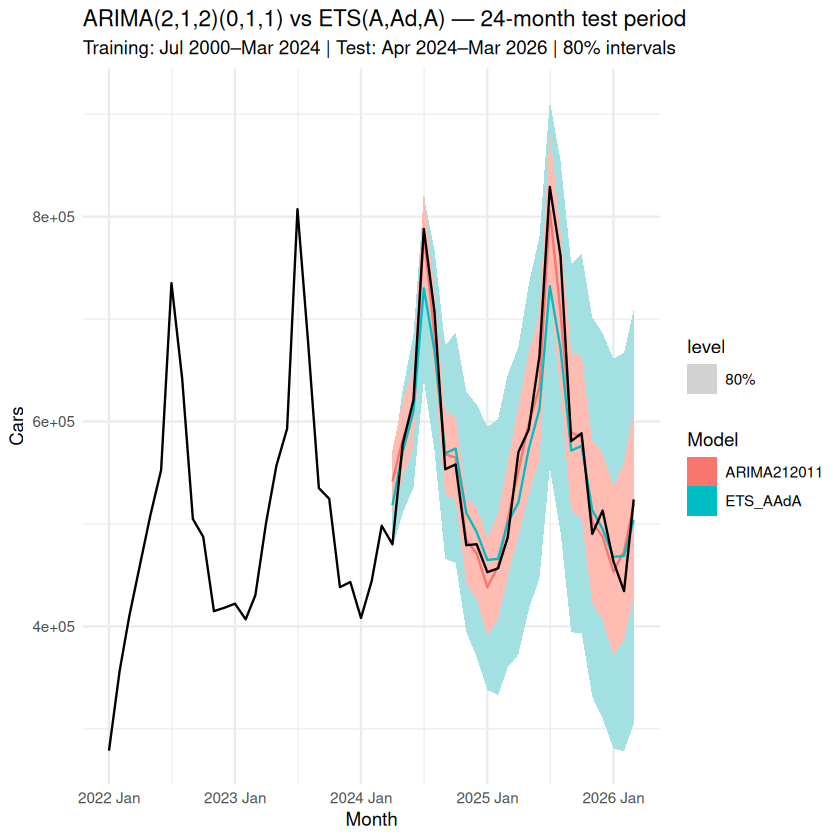

In [30]:
# CV accuracy side-by-side: best ARIMA vs best ETS
# arima212011
# ets_AAdA
bind_rows(
  cv_acc     %>% filter(.model == "arima212011"),
  ets_cv_acc %>% filter(.model == "ets_AAdA")
) %>%
  arrange(h, RMSE)


train <- traffic_ts %>% filter_index(. ~ "2024 Mar")
test  <- traffic_ts %>% filter_index("2024 Apr" ~ .)

fit_compare <- train %>%
  model(
    ARIMA212011 = ARIMA(box_cox(Cars, lambda) ~ covid +
                          imp_2020_apr + imp_2020_may + imp_2020_mar +
                          pdq(2,1,2) + PDQ(0,1,1)),
    ETS_AAdA = ETS(box_cox(Cars, lambda) ~ error("A") + trend("Ad") + season("A"))
  )

fc_compare <- fit_compare %>% forecast(new_data = test)

accuracy(fc_compare, traffic_ts) %>%
  select(.model, RMSE, MAE, MAPE, MASE) %>%
  arrange(RMSE)

fc_compare %>%
  autoplot(traffic_ts %>% filter_index("2022 Jan" ~ .), level = 80) +
  labs(
    title = "ARIMA(2,1,2)(0,1,1) vs ETS(A,Ad,A) — 24-month test period",
    subtitle = "Training: Jul 2000–Mar 2024 | Test: Apr 2024–Mar 2026 | 80% intervals",
    x = "Month", y = "Cars",
    color = "Model", fill = "Model"
  ) +
  theme_minimal()

### Final Forecasts

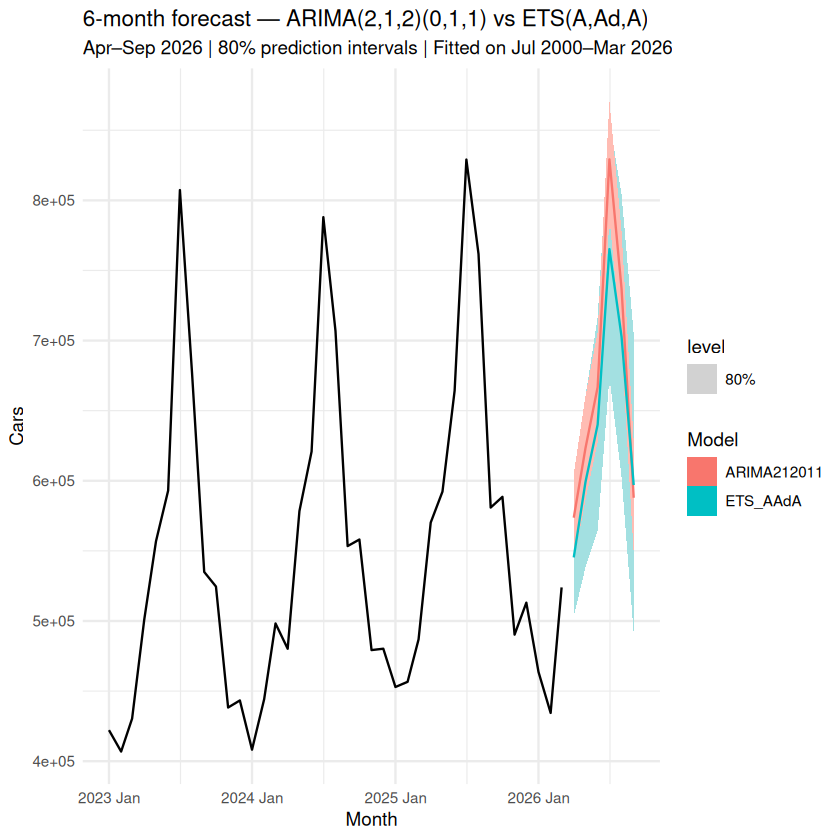

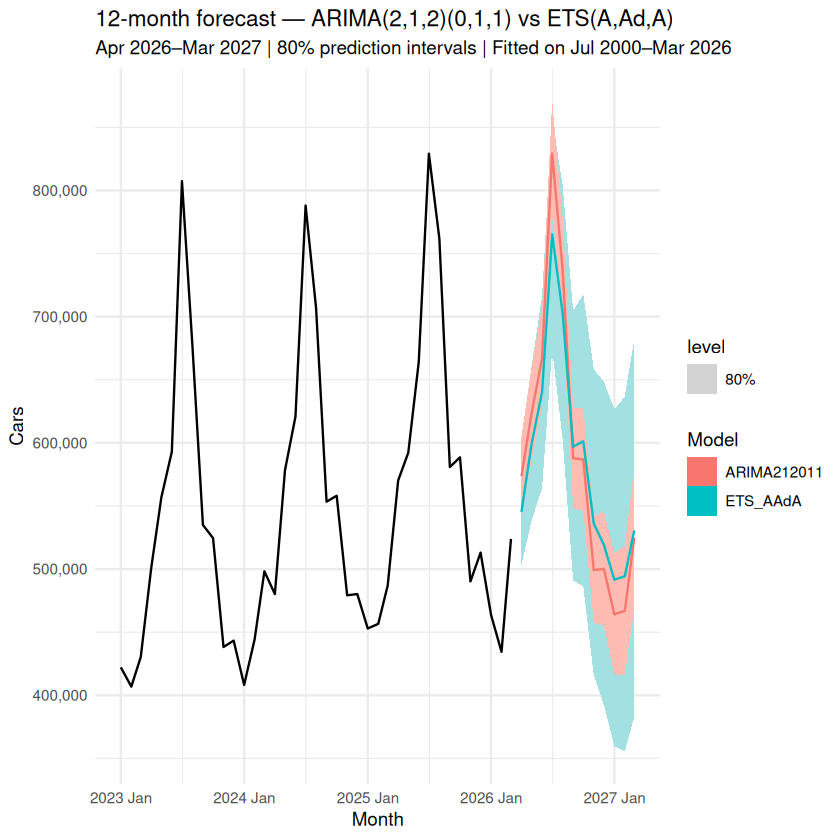

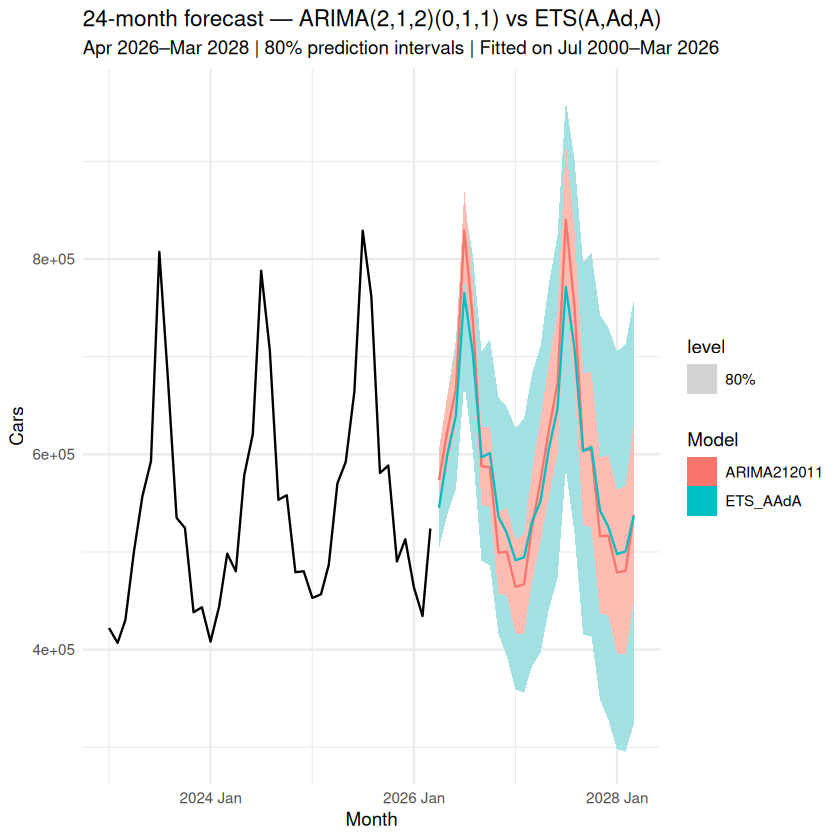

In [31]:
# Fit both best models on ALL available data (Jul 2000 – Mar 2026)
fit_final <- traffic_ts %>%
  model(
    ARIMA212011 = ARIMA(box_cox(Cars, lambda) ~ covid +
                          imp_2020_apr + imp_2020_may + imp_2020_mar +
                          pdq(2,1,2) + PDQ(0,1,1)),
    ETS_AAdA = ETS(box_cox(Cars, lambda) ~ error("A") + trend("Ad") + season("A"))
  )

# Future xreg: no COVID, no impulses; ETS ignores these extra columns
future_xreg <- new_data(traffic_ts, 24) %>%
  mutate(covid = 0L, imp_2020_apr = 0L, imp_2020_may = 0L, imp_2020_mar = 0L)

# 6-month forecast
fit_final %>%
  forecast(new_data = head(future_xreg, 6)) %>%
  autoplot(traffic_ts %>% filter_index("2023 Jan" ~ .), level = 80) +
  labs(
    title = "6-month forecast — ARIMA(2,1,2)(0,1,1) vs ETS(A,Ad,A)",
    subtitle = "Apr–Sep 2026 | 80% prediction intervals | Fitted on Jul 2000–Mar 2026",
    x = "Month", y = "Cars",
    color = "Model", fill = "Model"
  ) +
  theme_minimal()

# 12-month forecast
fit_final %>%
  forecast(new_data = head(future_xreg, 12)) %>%
  autoplot(traffic_ts %>% filter_index("2023 Jan" ~ .), level = 80) +
  labs(
    title = "12-month forecast — ARIMA(2,1,2)(0,1,1) vs ETS(A,Ad,A)",
    subtitle = "Apr 2026–Mar 2027 | 80% prediction intervals | Fitted on Jul 2000–Mar 2026",
    x = "Month", y = "Cars",
    color = "Model", fill = "Model"
  ) +
  scale_y_continuous(labels = scales::comma) +
  theme_minimal()

# 24-month forecast
fit_final %>%
  forecast(new_data = future_xreg) %>%
  autoplot(traffic_ts %>% filter_index("2023 Jan" ~ .), level = 80) +
  labs(
    title = "24-month forecast — ARIMA(2,1,2)(0,1,1) vs ETS(A,Ad,A)",
    subtitle = "Apr 2026–Mar 2028 | 80% prediction intervals | Fitted on Jul 2000–Mar 2026",
    x = "Month", y = "Cars",
    color = "Model", fill = "Model"
  ) +
  theme_minimal()

In [32]:
# Point forecast table — both models, all 24 months
fit_final %>%
  forecast(new_data = future_xreg) %>%
  as_tibble() %>%
  select(DateMonth, .model, .mean) %>%
  pivot_wider(names_from = .model, values_from = .mean) %>%
  mutate(across(where(is.numeric), ~ round(., 0))) %>%
  print(n = 24)

# A tibble: 24 × 3
   DateMonth ARIMA212011 ETS_AAdA
       <mth>       <dbl>    <dbl>
 1  2026 Apr      573684   545345
 2  2026 May      623386   599234
 3  2026 Jun      666824   640040
 4  2026 Jul      829232   765212
 5  2026 Aug      736961   702728
 6  2026 Sep      587886   596958
 7  2026 Oct      586772   601249
 8  2026 Nov      499228   536118
 9  2026 Dec      500190   519277
10  2027 Jan      464198   491608
11  2027 Feb      466910   494372
12  2027 Mar      524842   530642
13  2027 Apr      572944   551960
14  2027 May      624814   605730
15  2027 Jun      672601   646439
16  2027 Jul      840235   771456
17  2027 Aug      751842   708958
18  2027 Sep      604712   603246
19  2027 Oct      604667   607481
20  2027 Nov      516445   542404
21  2027 Dec      516504   525549
22  2028 Jan      479103   497897
23  2028 Feb      480710   500615
24  2028 Mar      538088   536766
